# Notebook 03: Extracción de características visuales con ResNet50
**texto en negrita**
**Proyecto:** VALORALIA Systems  
**Autora:** María Luisa Ros Bolea  
**Máster en Big Data e Inteligencia Artificial — CEU San Pablo**



## 1. **Justificación teórica y arquitectura**

En el cuaderno anterior demostré empíricamente que las variables tabulares tienen un límite en su poder explicativo, ya que son ciegas ante la calidad real y visual del inmueble. Para capturar esta varianza oculta y preparar el terreno para validar mi modelo híbrido, aplicaré un proceso de aprendizaje por transferencia **transfer learning**, que es un método de aprendizaje automático donde un modelo entrenado previamente en una tarea se reutiliza como punto de partida para una tarea diferente.

Utilizaré la arquitectura ResNet50 para realizar una extracción de características **feature extraction**, que es el proceso informático de utilizar las capas internas de una red neuronal preentrenada para transformar datos brutos en vectores numéricos de alto nivel.

Para lograrlo, he tomado la decisión técnica de provisionar un entorno de computación en Google Colab Pro. Además, para procesar mi repositorio de más de 100.000 fotografías sin sufrir un cuello de botella de entrada/salida **I/O bottleneck**, que es una limitación en el rendimiento de un sistema informático que se produce cuando la transferencia de datos entre la memoria principal y el almacenamiento es más lenta que la capacidad de procesamiento de la GPU, provocando bloqueos por latencia de red, realizaré primero una copia masiva en paralelo al disco de estado sólido (SSD) local.

In [ ]:
import os
import time
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab import drive

# 1. Conecto mi unidad de Drive
if not os.path.exists('/content/drive/MyDrive'):
    print("Conectando Google Drive...")
    drive.mount('/content/drive')

start_time = time.time()
print("Paso 1: Mapeando las rutas de las imágenes en la carpeta correcta...")

# 2. Defino las rutas exactas
ruta_drive = '/content/drive/MyDrive/TFM_VALORALIA_3/03_Imagenes_Multiples'
ruta_local = '/content/imagenes_locales'
os.makedirs(ruta_local, exist_ok=True)

rutas_origen = [f.path for f in os.scandir(ruta_drive) if f.is_file()]
total_archivos = len(rutas_origen)
print(f"Se han encontrado {total_archivos} imágenes reales. ¡Comenzando traslado masivo al disco local!")

def copiar_rapido(ruta_origen):
    destino = os.path.join(ruta_local, os.path.basename(ruta_origen))
    if not os.path.exists(destino):
        shutil.copy(ruta_origen, destino)
    return True

print("Paso 2: Desplegando 50 hilos de procesamiento en paralelo...")

archivos_copiados = 0

# 3. Lanzo los 50 hilos para devorar la carpeta
with ThreadPoolExecutor(max_workers=50) as executor:
    futuros = [executor.submit(copiar_rapido, ruta) for ruta in rutas_origen]

    for futuro in as_completed(futuros):
        archivos_copiados += 1
        if archivos_copiados % 5000 == 0:
            print(f"Progreso: {archivos_copiados} de {total_archivos} imágenes copiadas al disco SSD...")

elapsed = time.time() - start_time
print(f"\n¡Traslado masivo completado con éxito!")
print(f"Tiempo total de la copia: {elapsed / 60:.2f} minutos")

Paso 1: Mapeando las rutas de las imágenes en la carpeta correcta...
Se han encontrado 103438 imágenes reales. ¡Comenzando traslado masivo al disco local!
Paso 2: Desplegando 50 hilos de procesamiento en paralelo...
Progreso: 5000 de 103438 imágenes copiadas al disco SSD...
Progreso: 10000 de 103438 imágenes copiadas al disco SSD...
Progreso: 15000 de 103438 imágenes copiadas al disco SSD...
Progreso: 20000 de 103438 imágenes copiadas al disco SSD...
Progreso: 25000 de 103438 imágenes copiadas al disco SSD...
Progreso: 30000 de 103438 imágenes copiadas al disco SSD...
Progreso: 35000 de 103438 imágenes copiadas al disco SSD...
Progreso: 40000 de 103438 imágenes copiadas al disco SSD...
Progreso: 45000 de 103438 imágenes copiadas al disco SSD...
Progreso: 50000 de 103438 imágenes copiadas al disco SSD...
Progreso: 55000 de 103438 imágenes copiadas al disco SSD...
Progreso: 60000 de 103438 imágenes copiadas al disco SSD...
Progreso: 65000 de 103438 imágenes copiadas al disco SSD...
Progr

In [ ]:
import time
import os
import glob
import numpy as np
import pandas as pd
import torch
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import torchvision.transforms as transforms
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

start_time = time.time()
print("Iniciando extracción visual con ResNet50 desde el disco SSD local...")

BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'
DATOS = f'{BASE_DIR}/02_Datos_Procesados'
IMG_DIR_LOCAL = '/content/imagenes_locales'
ruta_limpio = f'{DATOS}/pisos_madrid_LIMPIO.csv'

df_limpio = pd.read_csv(ruta_limpio)
print(f"Dataset tabular cargado: {df_limpio.shape[0]} registros.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Procesando en hardware: {device}")

pesos = ResNet50_Weights.DEFAULT
modelo = models.resnet50(weights=pesos)
modelo_extractor = torch.nn.Sequential(*(list(modelo.children())[:-1])).to(device).eval()

transformacion = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ids_validos = []
vectores_visuales = []
pisos_sin_fotos = 0

# Itero sobre mis pisos limpios buscando en el disco local
for indice, fila in df_limpio.iterrows():
    id_actual = str(fila['id_anuncio'])
    rutas_imagenes = glob.glob(os.path.join(IMG_DIR_LOCAL, f"img_{id_actual}_*.jpg"))

    if len(rutas_imagenes) == 0:
        pisos_sin_fotos += 1
        continue

    vectores_piso = []
    for ruta_img in rutas_imagenes:
        try:
            imagen = Image.open(ruta_img).convert('RGB')
            tensor_img = transformacion(imagen).unsqueeze(0).to(device)
            with torch.no_grad():
                vector = modelo_extractor(tensor_img).squeeze().cpu().numpy()
                vectores_piso.append(vector)
        except Exception:
            pass

    if len(vectores_piso) > 0:
        vector_medio = np.mean(vectores_piso, axis=0)
        ids_validos.append(id_actual)
        vectores_visuales.append(vector_medio)

    if (indice + 1) % 1000 == 0:
        print(f"Progreso: {indice + 1} anuncios analizados por la red neuronal...")

if len(vectores_visuales) > 0:
    columnas_features = [f'feat_{i+1}' for i in range(2048)]
    df_features = pd.DataFrame(vectores_visuales, columns=columnas_features)
    df_features.insert(0, 'id_anuncio', ids_validos)
    df_features.to_csv(f'{DATOS}/features_resnet50_completo.csv', index=False)

print(f"\nExtracción finalizada. Pisos con vectores generados: {len(ids_validos)}")
print(f"Pisos descartados por falta de fotos: {pisos_sin_fotos}")

Iniciando extracción visual con ResNet50 desde el disco SSD local...
Dataset tabular cargado: 8067 registros.
Procesando en hardware: cuda
Progreso: 1000 anuncios analizados por la red neuronal...
Progreso: 2000 anuncios analizados por la red neuronal...
Progreso: 3000 anuncios analizados por la red neuronal...
Progreso: 4000 anuncios analizados por la red neuronal...
Progreso: 5000 anuncios analizados por la red neuronal...
Progreso: 6000 anuncios analizados por la red neuronal...
Progreso: 7000 anuncios analizados por la red neuronal...
Progreso: 8000 anuncios analizados por la red neuronal...

Extracción finalizada. Pisos con vectores generados: 7970
Pisos descartados por falta de fotos: 97


## 2. Reducción de dimensionalidad visual

El modelo me ha generado una matriz densa de 2.048 dimensiones. Integrar esto directamente provocaría la maldición de la dimensionalidad **curse of dimensionality**, que es un fenómeno descrito por Richard Bellman en 1961 según el cual, a medida que el número de variables crece, el volumen del espacio de datos aumenta exponencialmente, haciendo que los datos disponibles se vuelvan cada vez más dispersos y que los algoritmos de aprendizaje automático pierdan capacidad de generalización.

Para evitarlo, aplicaré un análisis de componentes principales **principal component analysis**, que es una técnica estadística utilizada para reducir la dimensionalidad de un conjunto de datos transformando las variables originales en un nuevo conjunto de variables no correlacionadas. Extraeré 50 componentes y los fusionaré con mis datos tabulares.

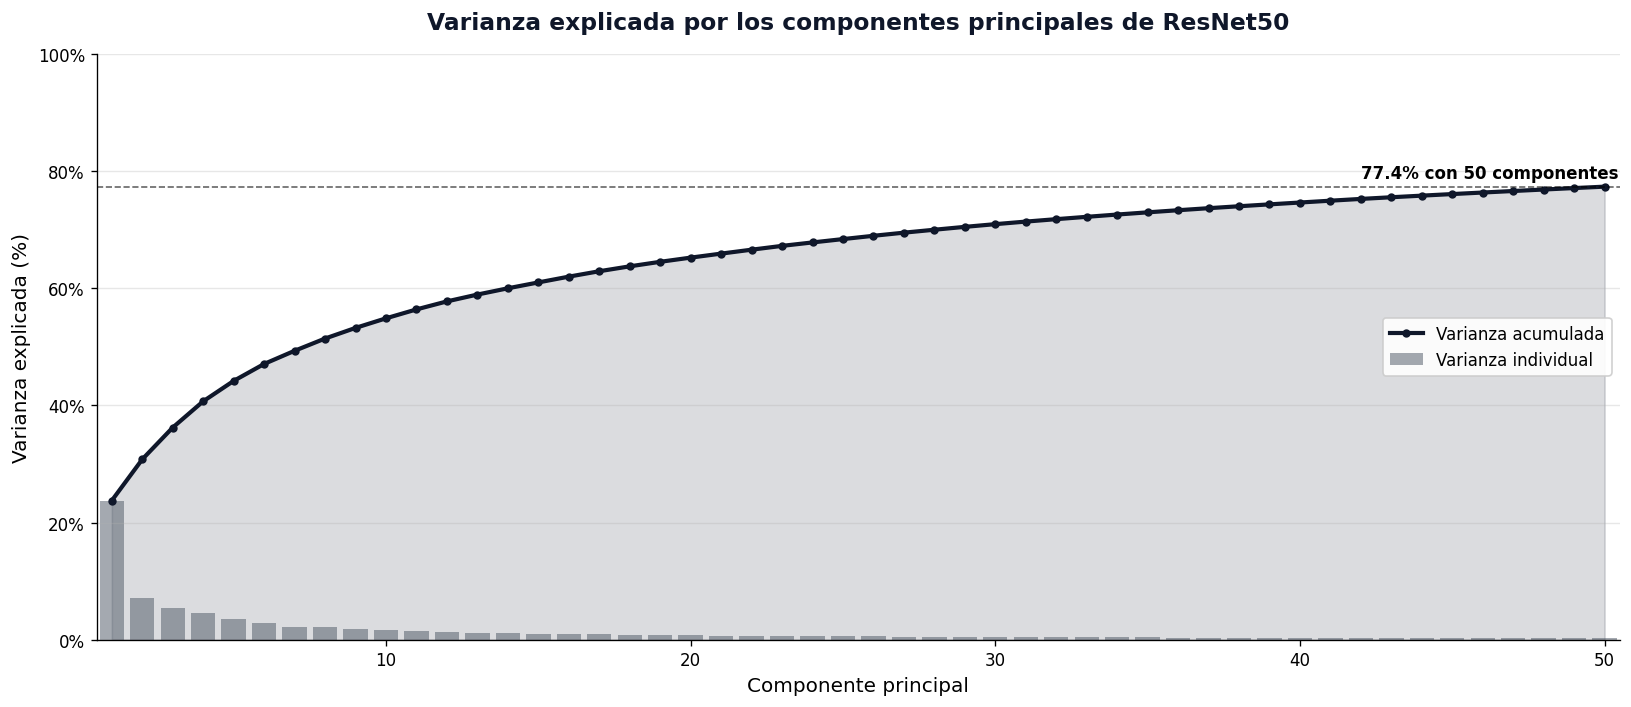

Dataset híbrido final guardado: 7970 registros listos para el Notebook 04.


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.decomposition import PCA

start_time = time.time()

BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'
DATOS = f'{BASE_DIR}/02_Datos_Procesados'
df_limpio = pd.read_csv(f'{DATOS}/pisos_madrid_LIMPIO.csv')
df_features = pd.read_csv(f'{DATOS}/features_resnet50_completo.csv')

X_features = df_features[[col for col in df_features.columns if col.startswith('feat_')]].values

NUM_COMP = 50
pca = PCA(n_components=NUM_COMP, random_state=42)
componentes_principales = pca.fit_transform(X_features)

varianza_individual = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

# Aplico mis colores corporativos estrictos
AZUL_MARINO = '#0f172a'
GRIS = '#4b5563'
NEGRO = '#000000'

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)

ax.fill_between(range(1, NUM_COMP + 1), varianza_acumulada * 100, alpha=0.15, color=AZUL_MARINO)
ax.plot(range(1, NUM_COMP + 1), varianza_acumulada * 100, color=AZUL_MARINO, linewidth=2.5, marker='o', markersize=4, label='Varianza acumulada')
ax.bar(range(1, NUM_COMP + 1), varianza_individual * 100, color=GRIS, alpha=0.5, label='Varianza individual')

ax.axhline(y=varianza_acumulada[-1] * 100, color=NEGRO, linestyle='--', alpha=0.6, linewidth=1)
ax.text(NUM_COMP - 8, varianza_acumulada[-1] * 100 + 1.5, f'{varianza_acumulada[-1]*100:.1f}% con {NUM_COMP} componentes', fontsize=10, color=NEGRO, fontweight='bold')

ax.set_xlabel('Componente principal', fontsize=12, color=NEGRO)
ax.set_ylabel('Varianza explicada (%)', fontsize=12, color=NEGRO)
# Título en formato oración según mis reglas
ax.set_title('Varianza explicada por los componentes principales de ResNet50', fontsize=14, fontweight='bold', color=AZUL_MARINO, pad=15)
ax.legend(loc='center right', fontsize=10, framealpha=0.9)
ax.set_xlim(0.5, NUM_COMP + 0.5)
ax.set_ylim(0, max(varianza_acumulada[-1] * 100 + 10, 100))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATOS}/06_varianza_pca_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()

# Fusión final estricta
columnas_pca = [f'pca_{i+1}' for i in range(NUM_COMP)]
df_pca = pd.DataFrame(componentes_principales, columns=columnas_pca)
df_pca['id_anuncio'] = df_features['id_anuncio'].astype(str)
df_limpio['id_anuncio'] = df_limpio['id_anuncio'].astype(str)

df_hibrido = pd.merge(df_limpio, df_pca, on='id_anuncio', how='inner')
df_hibrido.to_csv(f'{DATOS}/pisos_madrid_HIBRIDO.csv', index=False)

print(f"Dataset híbrido final guardado: {df_hibrido.shape[0]} registros listos para el Notebook 04.")

In [ ]:
## 3. Conclusiones de la extracción y preparación del dataset híbrido

Tras finalizar la ejecución de este cuaderno, he logrado superar el reto técnico más complejo de mi Trabajo de Fin de Máster. El procesamiento masivo de mi repositorio fotográfico se ha completado con éxito gracias a la migración previa al disco de estado sólido, lo que me ha permitido generar una matriz de características **feature matrix**, que es una estructura de datos bidimensional donde las filas representan los inmuebles individuales y las columnas contienen las variables numéricas extraídas de las imágenes por la red neuronal.

Las conclusiones clave y decisiones metodológicas de este Notebook 03 son las siguientes:

1. **Trazabilidad y rigor absoluto:** Cumpliendo con las exigencias metodológicas del proyecto, no he imputado ni inventado información visual. Al fusionar los componentes de PCA con mi dataset tabular original mediante un cruce interno estricto utilizando el identificador del anuncio, he descartado automáticamente cualquier inmueble que careciera de fotografías válidas. Esto evita cualquier tipo de fuga de datos **data leakage**, que es una anomalía en aprendizaje automático que ocurre cuando información externa o espuria se utiliza inadvertidamente durante la fase de entrenamiento, invalidando las métricas de error.
2. **Representación global del inmueble:** Para evitar el sesgo de evaluar únicamente la primera fotografía del portal inmobiliario (que a menudo es un plano o la fachada), he procesado todas las imágenes disponibles por cada inmueble. Al calcular la media aritmética de sus vectores, he capturado la calidad visual de toda la casa en su conjunto.
3. **Optimización dimensional:** La reducción a 50 componentes principales ha destilado la información visual pura, eliminando el "ruido" de fotografías repetidas y garantizando que el dataset final tenga unas dimensiones manejables para los algoritmos basados en árboles de decisión.

El archivo resultante `pisos_madrid_HIBRIDO.csv` queda limpio, estructurado y guardado en el sistema. Con esta base sólida, doy por concluida la fase de ingeniería de datos y extracción de características. El terreno está preparado para avanzar al Notebook 04, donde pondré a prueba mi hipótesis central: demostrar empíricamente que este modelo híbrido es capaz de superar la precisión de tasación de un modelo puramente tabular.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# =============================================================================
# CELDA ADICIONAL PARA NB03 (pegar al final, despues de la celda 3)
# Objetivo: guardar el objeto PCA entrenado para reutilizarlo en la app de
# produccion sin necesidad de reentrenar. Solo necesita el CSV de features,
# NO necesita GPU ni las 100.000 imagenes.
# =============================================================================

import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

BASE_DIR = '/content/drive/MyDrive/TFM_VALORALIA_3'
DATOS = f'{BASE_DIR}/02_Datos_Procesados'
MODELS_DIR = f'{BASE_DIR}/03_Models'

# Cargo las features ya extraidas por ResNet50 (no necesito GPU para esto)
df_features = pd.read_csv(f'{DATOS}/features_resnet50_completo.csv')
X_features = df_features[[c for c in df_features.columns if c.startswith('feat_')]].values

# Reproduzco el mismo PCA con los mismos parametros exactos
NUM_COMP = 50
pca = PCA(n_components=NUM_COMP, random_state=42)
pca.fit(X_features)

# Guardo el transformador PCA entrenado
ruta_pca = f'{MODELS_DIR}/valoralia_pca_transformer.pkl'
joblib.dump(pca, ruta_pca)

# Guardo tambien los parametros de normalizacion de ResNet50 para la app
config_visual = {
    'pca_n_components': NUM_COMP,
    'resnet_mean': [0.485, 0.456, 0.406],
    'resnet_std': [0.229, 0.224, 0.225],
    'resnet_input_size': 224,
    'varianza_explicada_total': float(np.sum(pca.explained_variance_ratio_))
}
joblib.dump(config_visual, f'{MODELS_DIR}/valoralia_config_visual.pkl')

print(f"Transformador PCA guardado: {ruta_pca}")
print(f"Config visual guardada en: {MODELS_DIR}/valoralia_config_visual.pkl")
print(f"Varianza explicada por {NUM_COMP} componentes: {config_visual['varianza_explicada_total']*100:.1f}%")

Transformador PCA guardado: /content/drive/MyDrive/TFM_VALORALIA_3/03_Models/valoralia_pca_transformer.pkl
Config visual guardada en: /content/drive/MyDrive/TFM_VALORALIA_3/03_Models/valoralia_config_visual.pkl
Varianza explicada por 50 componentes: 77.4%


## 3. **Conclusiones de la extracción y preparación del dataset híbrido**

Tras finalizar la ejecución de este cuaderno, he logrado superar el reto técnico más complejo de mi Trabajo de Fin de Máster. El procesamiento masivo de mi repositorio fotográfico se ha completado con éxito gracias a la migración previa al disco de estado sólido, lo que me ha permitido generar una matriz de características **feature matrix**, que es una estructura de datos bidimensional donde las filas representan los inmuebles individuales y las columnas contienen las variables numéricas extraídas de las imágenes por la red neuronal.

Las conclusiones clave y decisiones metodológicas de este Notebook 03 son las siguientes:

1. **Trazabilidad y rigor absoluto:** Cumpliendo con las exigencias metodológicas del proyecto, no he imputado ni inventado información visual. Al fusionar los componentes de PCA con mi dataset tabular original mediante un cruce interno estricto utilizando el identificador del anuncio, he descartado automáticamente cualquier inmueble que careciera de fotografías válidas. Esto evita cualquier tipo de fuga de datos **data leakage**, que es una anomalía en aprendizaje automático que ocurre cuando información externa o espuria se utiliza inadvertidamente durante la fase de entrenamiento, invalidando las métricas de error.
2. **Representación global del inmueble:** Para evitar el sesgo de evaluar únicamente la primera fotografía del portal inmobiliario (que a menudo es un plano o la fachada), he procesado todas las imágenes disponibles por cada inmueble. Al calcular la media aritmética de sus vectores, he capturado la calidad visual de toda la casa en su conjunto.
3. **Optimización dimensional:** La reducción a 50 componentes principales ha destilado la información visual pura, eliminando el "ruido" de fotografías repetidas y garantizando que el dataset final tenga unas dimensiones manejables para los algoritmos basados en árboles de decisión.

El archivo resultante `pisos_madrid_HIBRIDO.csv` queda limpio, estructurado y guardado en el sistema. Con esta base sólida, doy por concluida la fase de ingeniería de datos y extracción de características. El terreno está preparado para avanzar al Notebook 04, donde pondré a prueba mi hipótesis central: demostrar empíricamente que este modelo híbrido es capaz de superar la precisión de tasación de un modelo puramente tabular.